In [1]:
def sample_conditional_pt(x0, x1, t, sigma):
    """
    Draw a sample from the probability path N(t * x1 + (1 - t) * x0, sigma), see (Eq.14) [1].

    Parameters
    ----------
    x0 : Tensor, shape (bs, *dim)
        represents the source minibatch
    x1 : Tensor, shape (bs, *dim)
        represents the target minibatch
    t : FloatTensor, shape (bs)

    Returns
    -------
    xt : Tensor, shape (bs, *dim)

    References
    ----------
    [1] Improving and Generalizing Flow-Based Generative Models with minibatch optimal transport, Preprint, Tong et al.
    """
    t = t.reshape(-1, *([1] * (x0.dim() - 1)))
    mu_t = t * x1 + (1 - t) * x0
    epsilon = torch.randn_like(x0)
    return mu_t + sigma * epsilon

In [2]:
def compute_conditional_vector_field(x0, x1):
    """
    Compute the conditional vector field ut(x1|x0) = x1 - x0, see Eq.(15) [1].

    Parameters
    ----------
    x0 : Tensor, shape (bs, *dim)
        represents the source minibatch
    x1 : Tensor, shape (bs, *dim)
        represents the target minibatch

    Returns
    -------
    ut : conditional vector field ut(x1|x0) = x1 - x0

    References
    ----------
    [1] Improving and Generalizing Flow-Based Generative Models with minibatch optimal transport, Preprint, Tong et al.
    """
    return x1 - x0

In [3]:
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import ot as pot
import torch
import torchdyn
from torchdyn.core import NeuralODE
from torchdyn.datasets import generate_moons
from math import dist


from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

savedir = "models/8gaussian-moons"
os.makedirs(savedir, exist_ok=True)

In [21]:
sigma = 0.1
dim = 2
batch_size = 256
model = MLP(dim=dim, time_varying=True, w=128)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): SELU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SELU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): SELU()
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [22]:
# First distribution (N1) parameters
mu1 = 3.0
var1 = 1.0
std1 = math.sqrt(var1)

# Second distribution (N1) parameters
mu2 = -2.0
var2 = 2.0
std2 = math.sqrt(var2)

def sample_N1(n):
    return torch.randn(n, 1) * std1 + mu1

def sample_N2(n):
    return torch.randn(n, 1) * std2 + mu2

def gaussian_pdf(x, mu, std):
    return (1.0 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / std) ** 2)

def true_mixture_pdf(x):
    return (1/3) * gaussian_pdf(x, mu1, std1) + (2/3) * gaussian_pdf(x, mu2, std2)

In [23]:
# First method
option1_data = torch.cat([
    sample_N1(1200),
    sample_N2(1800)
], dim=0)

def sample_target_option1(batch_size):
    idx = torch.randint(0, option1_data.shape[0], (batch_size,))
    return option1_data[idx]

In [ ]:
# Second method
option2_N1 = sample_N1(1500)
option2_N2 = sample_N2(1500)

def sample_target_option2(batch_size):
    # Draw all choices at once: 1 = N2 (prob 0.6), 0 = N1 (prob 0.4)
    mask = torch.bernoulli(torch.full((batch_size,), 0.60)).bool()

    n2_count = mask.sum().item()
    n1_count = batch_size - n2_count

    idx1 = torch.randint(0, option2_N1.shape[0], (n1_count,))
    idx2 = torch.randint(0, option2_N2.shape[0], (n2_count,))

    samples = torch.empty(batch_size, 1)
    samples[~mask] = option2_N1[idx1]
    samples[mask]  = option2_N2[idx2]

    return samples

In [33]:
def sample_target_option1(batch_size):
    n1 = int(batch_size / 3)
    n2 = batch_size - n1
    return torch.cat([sample_N1(n1), sample_N2(n2)], dim=0)

def sample_target_option2(batch_size):
    mask = torch.bernoulli(torch.full((batch_size,), 2/3)).bool()
    n2_count = mask.sum().item()
    n1_count = batch_size - n2_count
    samples = torch.empty(batch_size, 1)
    samples[~mask] = sample_N1(n1_count)
    samples[mask]  = sample_N2(n2_count)
    return samples

In [34]:
# Third Method

option3_N1 = sample_N1(1500)
option3_N2 = sample_N2(1500)

option3_data = torch.cat([option3_N1, option3_N2], dim=0)  # shape: (3000, 1)

option3_weights = torch.cat([
    torch.ones(1500),
    2.0 * torch.ones(1500)
], dim=0)

def stochastic_universal_sampling(weights, n_samples):
    total_weight = weights.sum().item()
    step = total_weight / n_samples

    # Random start in [0, step)
    start = torch.rand(1).item() * step

    # Equally spaced pointers
    pointers = [start + i * step for i in range(n_samples)]

    # Cumulative weight array
    cumulative = torch.cumsum(weights, dim=0)

    # Walk through cumulative weights and collect selected indices
    indices = []
    i = 0
    for p in pointers:
        while cumulative[i].item() < p:
            i += 1
        indices.append(i)

    return torch.tensor(indices, dtype=torch.long)

def sample_target_option3(batch_size):
    idx = stochastic_universal_sampling(option3_weights, batch_size)
    return option3_data[idx]

### Universal Sampling

In the third method we use Stochastic Universal Sampling which is a form of sampling where we try and draw samples according to the weights. In this implementation we draw 1500 samples from both N1 and N2 and then we combine those. Then we add weights to those corresponding sections favoring N2 with weight 2 and N1 with only weight of 1. We determine how many steps we need and choose a ranodm starting position and proceed to put equally spaced pointers throughout the cumulative weight distribution. Then whichever locations those pointers land on are the samples that we choose from the concatenated tensor.

## Training Models

In [35]:
import time
import copy
import torch
import numpy as np

#parameters
sigma = 0.1
dim = 1
batch_size = 1024
total_iters = 20000
checkpoints = [2500, 5000, 7500, 10000, 12500, 15000, 17500, 20000]

def train_flow_model_with_checkpoints(sample_target_fn, model_name,
                                       total_iters=30000, checkpoints=[5000, 10000, 20000]):
    model = MLP(dim=dim, time_varying=True)
    optimizer = torch.optim.Adam(model.parameters())
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_iters)


    losses = []
    checkpoint_models = {}
    checkpoint_losses = {}
    start = time.time()

    for k in range(total_iters):
        optimizer.zero_grad()

        x0 = torch.randn(batch_size, 1)
        x1 = sample_target_fn(batch_size)

        t = torch.rand(x0.shape[0]).type_as(x0)
        xt = sample_conditional_pt(x0, x1, t, sigma=0.1)
        ut = compute_conditional_vector_field(x0, x1)

        vt = model(torch.cat([xt, t[:, None]], dim=-1))
        loss = torch.mean((vt - ut) ** 2)

        loss.backward()
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())

        if (k + 1) in checkpoints:
            checkpoint_models[k + 1] = copy.deepcopy(model.state_dict())
            checkpoint_losses[k + 1] = loss.item()
            end = time.time()
            print(f"{model_name} | Iter {k+1}: loss = {loss.item():0.4f} | elapsed = {(end - start):0.2f}s")
            start = end

    return model, losses, checkpoint_models, checkpoint_losses


print("Training Option 1...")
model_option1, losses_option1, checkpoints_option1, checkpoint_losses_option1 = \
    train_flow_model_with_checkpoints(sample_target_option1, "Option 1",
                                      total_iters=total_iters, checkpoints=checkpoints)

print("\nTraining Option 2...")
model_option2, losses_option2, checkpoints_option2, checkpoint_losses_option2 = \
    train_flow_model_with_checkpoints(sample_target_option2, "Option 2",
                                      total_iters=total_iters, checkpoints=checkpoints)

print("\nTraining Option 3...")
model_option3, losses_option3, checkpoints_option3, checkpoint_losses_option3 = \
    train_flow_model_with_checkpoints(sample_target_option3, "Option 3",
                                      total_iters=total_iters, checkpoints=checkpoints)

print("\nAll models trained.")


Training Option 1...
Option 1 | Iter 2500: loss = 3.9702 | elapsed = 5.44s
Option 1 | Iter 5000: loss = 3.9755 | elapsed = 5.64s
Option 1 | Iter 7500: loss = 3.8153 | elapsed = 5.46s
Option 1 | Iter 10000: loss = 4.2044 | elapsed = 5.81s
Option 1 | Iter 12500: loss = 4.0783 | elapsed = 5.96s
Option 1 | Iter 15000: loss = 3.9497 | elapsed = 5.85s
Option 1 | Iter 17500: loss = 4.0051 | elapsed = 5.57s
Option 1 | Iter 20000: loss = 4.0443 | elapsed = 6.33s

Training Option 2...
Option 2 | Iter 2500: loss = 3.8506 | elapsed = 6.38s
Option 2 | Iter 5000: loss = 4.0483 | elapsed = 5.78s
Option 2 | Iter 7500: loss = 3.5192 | elapsed = 5.98s
Option 2 | Iter 10000: loss = 3.9582 | elapsed = 5.84s
Option 2 | Iter 12500: loss = 4.2259 | elapsed = 5.98s
Option 2 | Iter 15000: loss = 4.0392 | elapsed = 5.84s
Option 2 | Iter 17500: loss = 3.8957 | elapsed = 5.92s
Option 2 | Iter 20000: loss = 4.1140 | elapsed = 5.76s

Training Option 3...
Option 3 | Iter 2500: loss = 4.1436 | elapsed = 122.06s
Optio

In [36]:
print("\nCheckpoint Loss Summary")
#first 20 losses for option 1
print(losses_option1[:20])
print("--------------------------------------------------")
for cp in checkpoints:
    l1 = checkpoint_losses_option1.get(cp, float('nan'))
    l2 = checkpoint_losses_option2.get(cp, float('nan'))
    l3 = checkpoint_losses_option3.get(cp, float('nan'))
    print(f"{cp:>6} iters | Option 1: {l1:.6f} | Option 2: {l2:.6f} | Option 3: {l3:.6f}")




Checkpoint Loss Summary
[7.935757637023926, 7.534186363220215, 6.29023551940918, 5.855020523071289, 5.6194281578063965, 5.126616477966309, 4.93281364440918, 4.7456817626953125, 4.996411323547363, 4.85579252243042, 4.775718688964844, 4.21124792098999, 4.685458183288574, 5.007303237915039, 5.115754127502441, 4.933113098144531, 4.082605361938477, 4.881852149963379, 4.8520894050598145, 4.649974346160889]
--------------------------------------------------
  2500 iters | Option 1: 3.970225 | Option 2: 3.850578 | Option 3: 4.143591
  5000 iters | Option 1: 3.975454 | Option 2: 4.048288 | Option 3: 3.816928
  7500 iters | Option 1: 3.815258 | Option 2: 3.519206 | Option 3: 3.989606
 10000 iters | Option 1: 4.204367 | Option 2: 3.958179 | Option 3: 3.959913
 12500 iters | Option 1: 4.078280 | Option 2: 4.225875 | Option 3: 4.341656
 15000 iters | Option 1: 3.949668 | Option 2: 4.039165 | Option 3: 4.367336
 17500 iters | Option 1: 4.005054 | Option 2: 3.895687 | Option 3: 3.818387
 20000 iters

In [6]:
def generate_fm_samples(trained_model, n_samples=1000):
    node = NeuralODE(
        torch_wrapper(trained_model),
        solver="dopri5",
        sensitivity="adjoint",
        atol=1e-4,
        rtol=1e-4
    )

    with torch.no_grad():
        x0 = torch.randn(n_samples, 1)
        traj = node.trajectory(x0, t_span=torch.linspace(0, 1, 100))
        x1_gen = traj[-1].cpu().numpy().flatten()

    return x1_gen

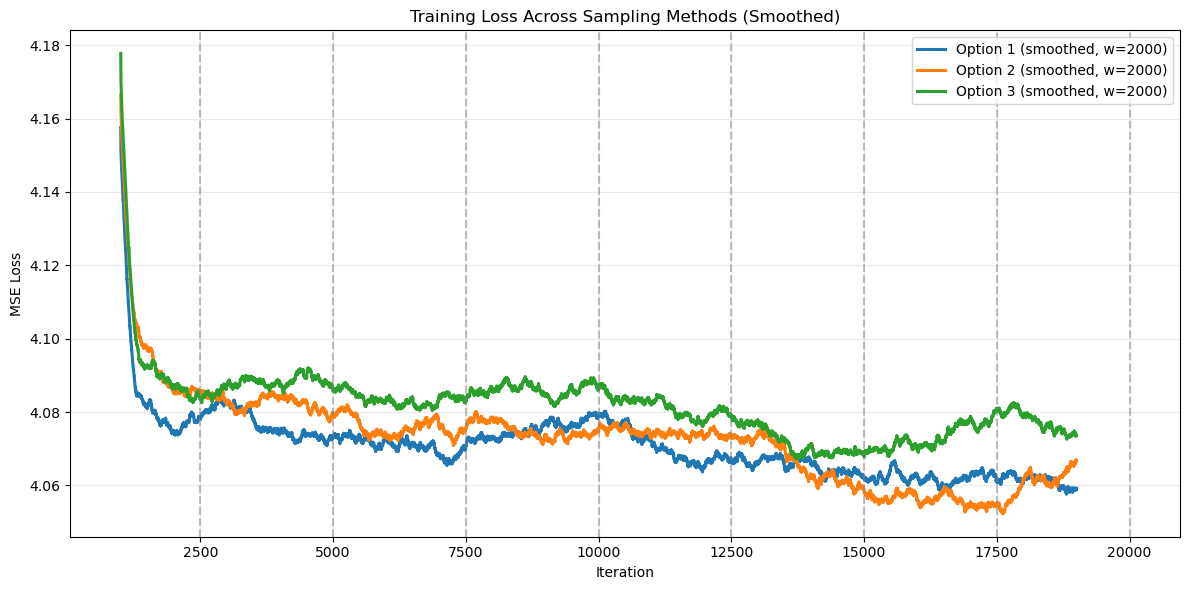

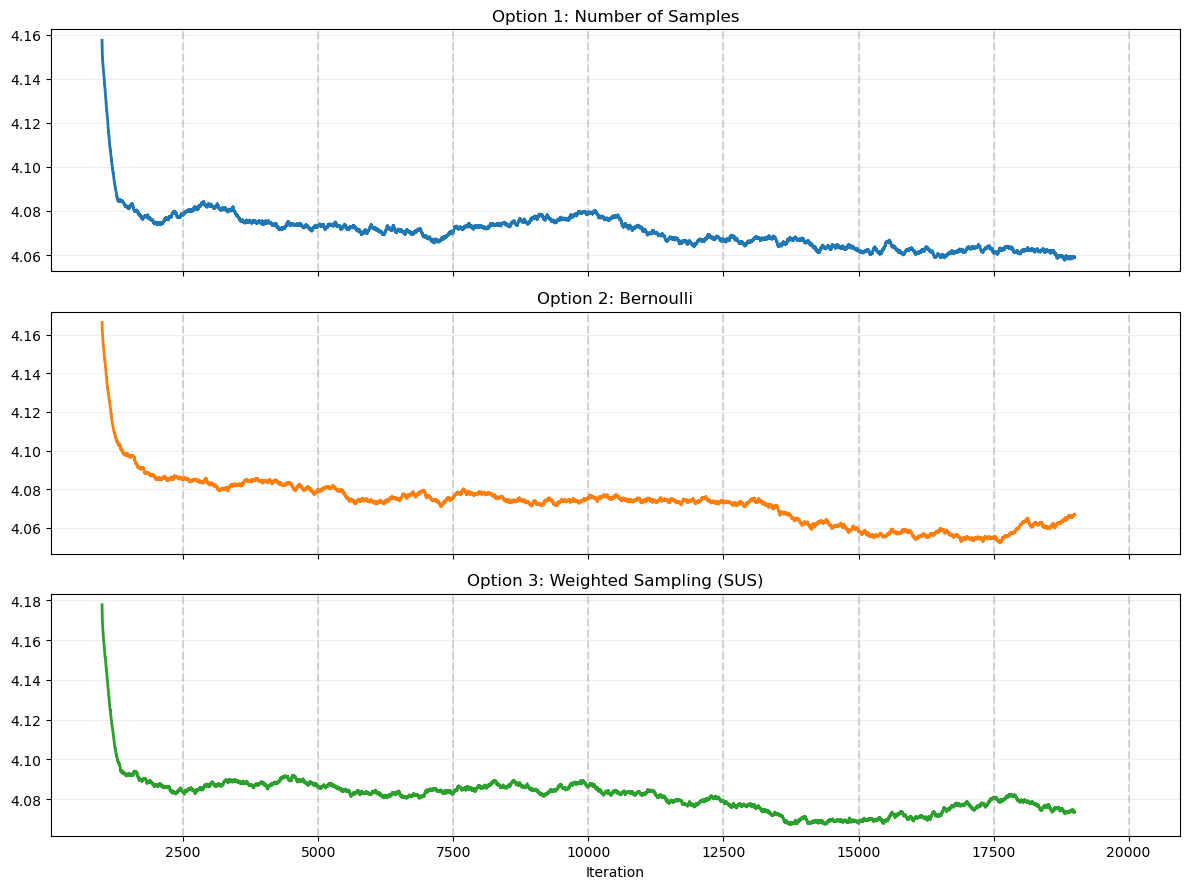

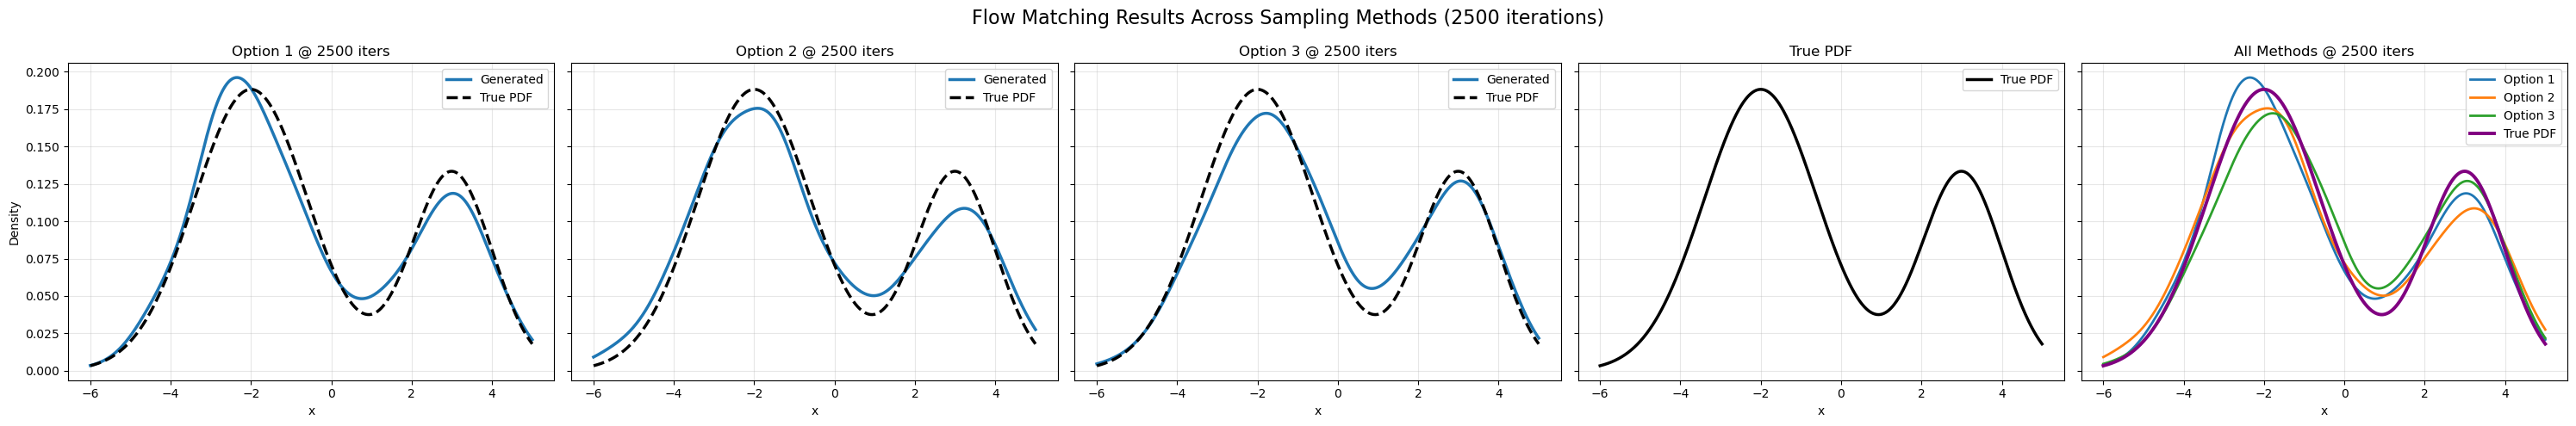

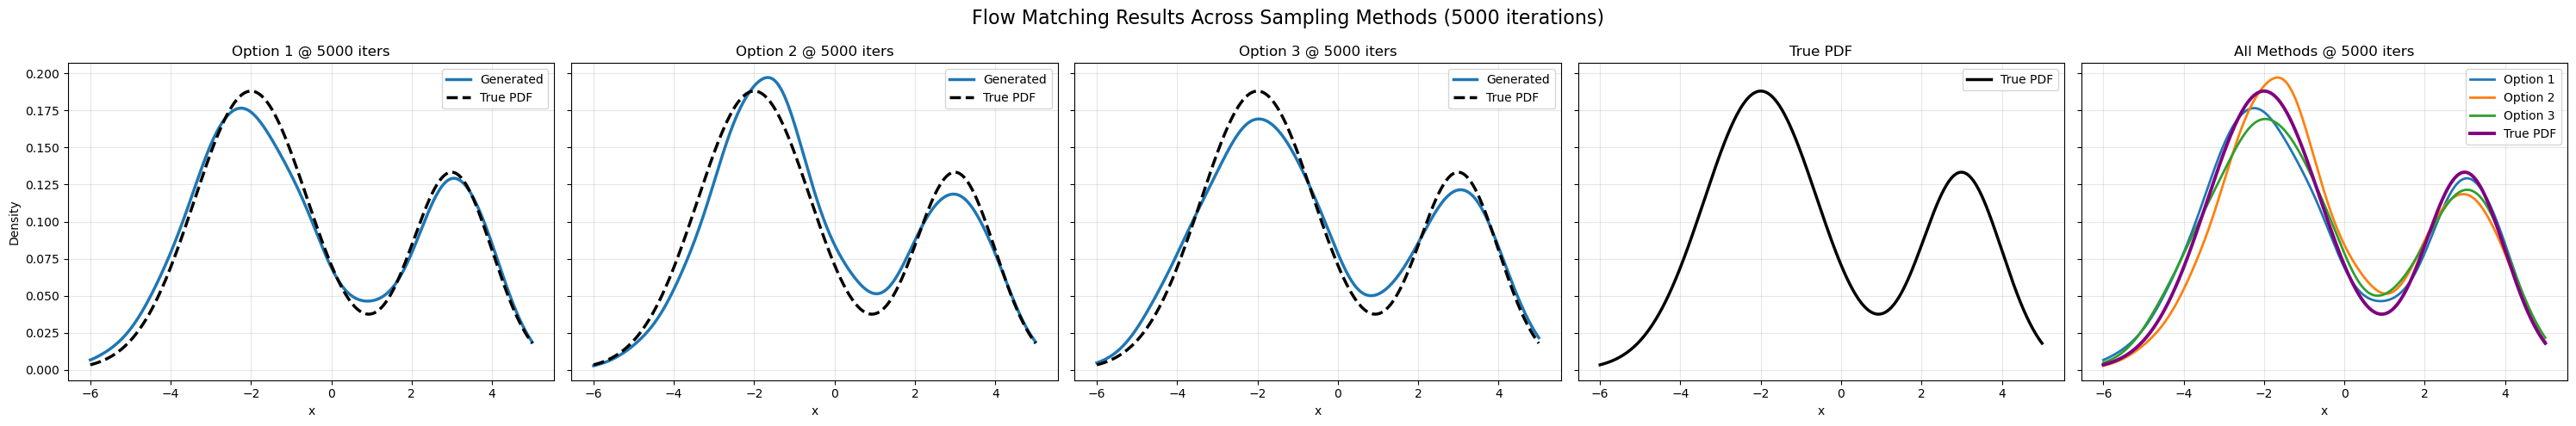

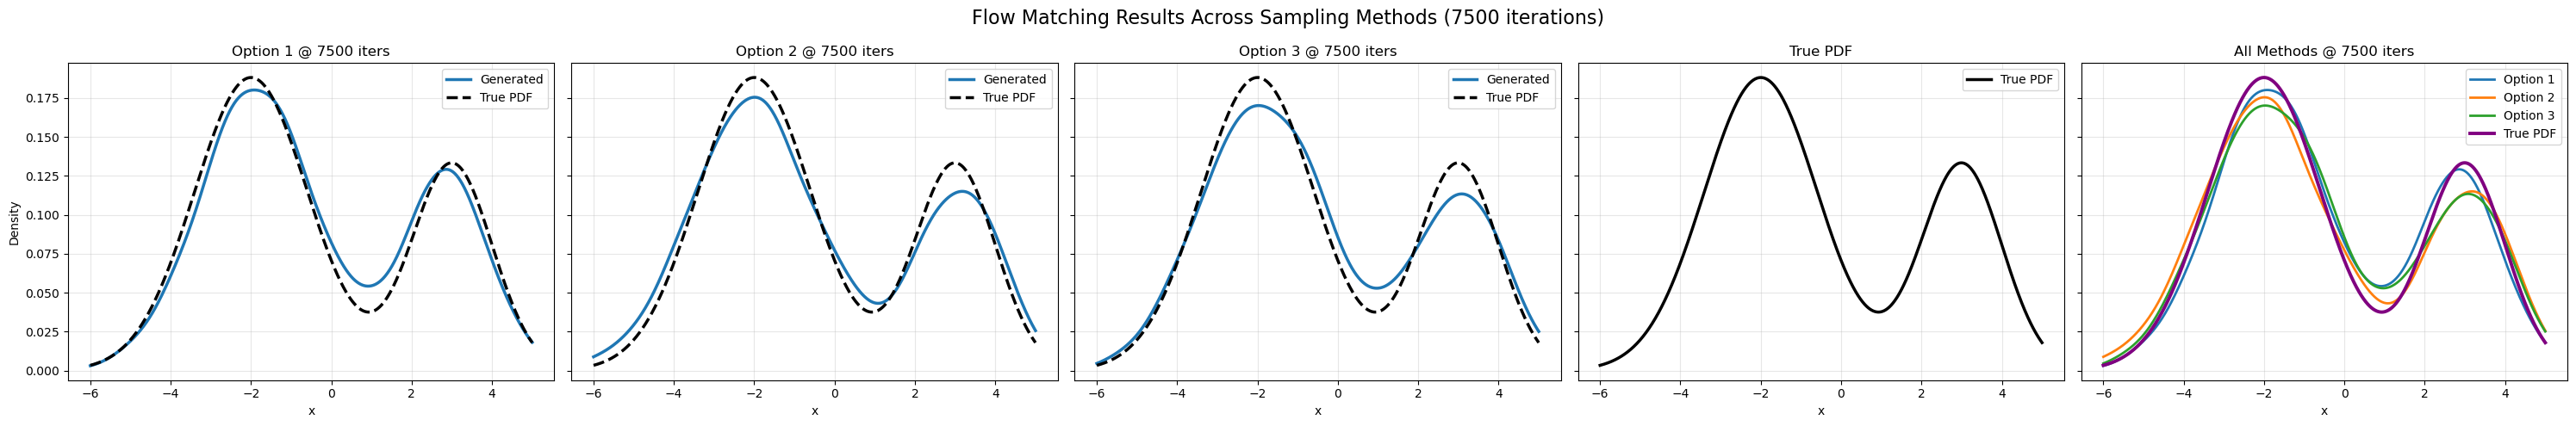

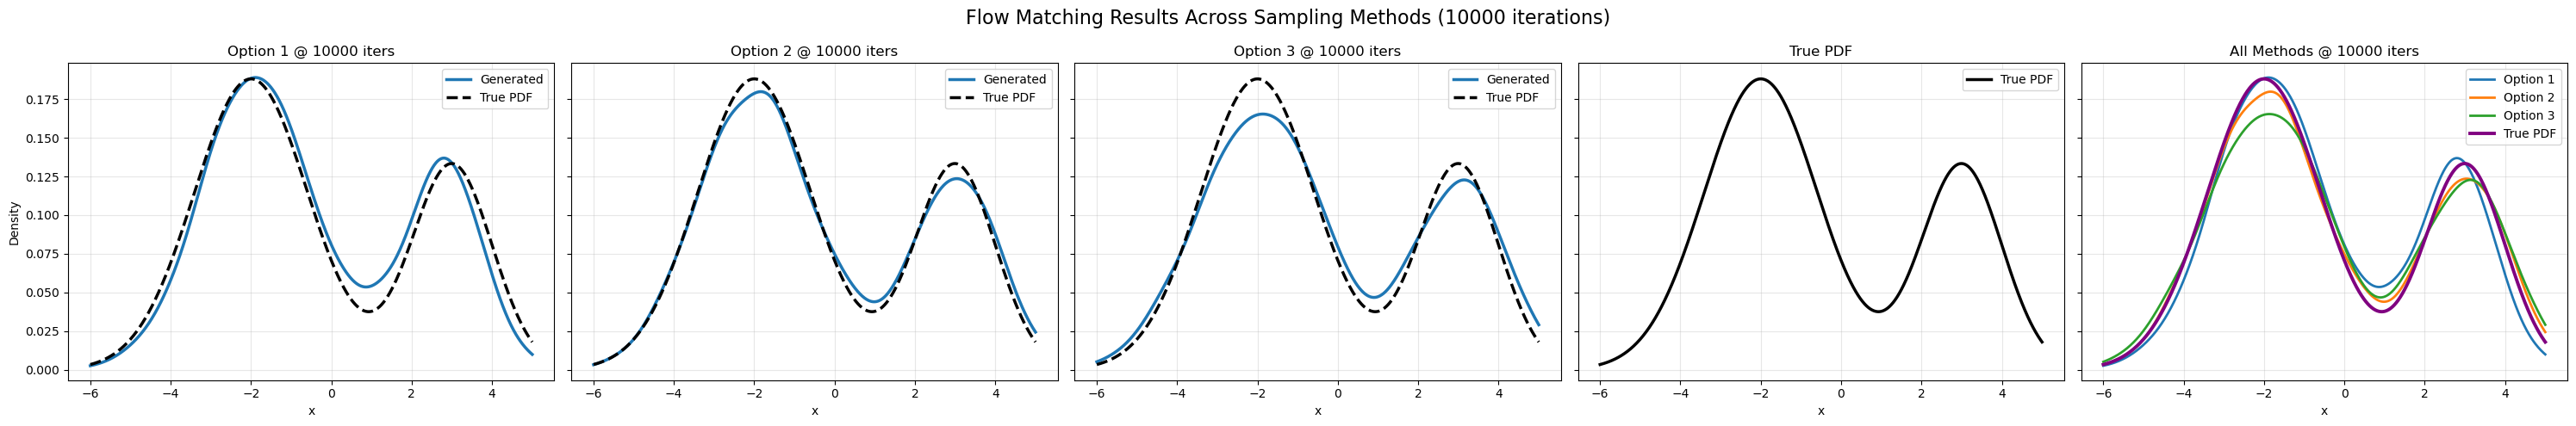

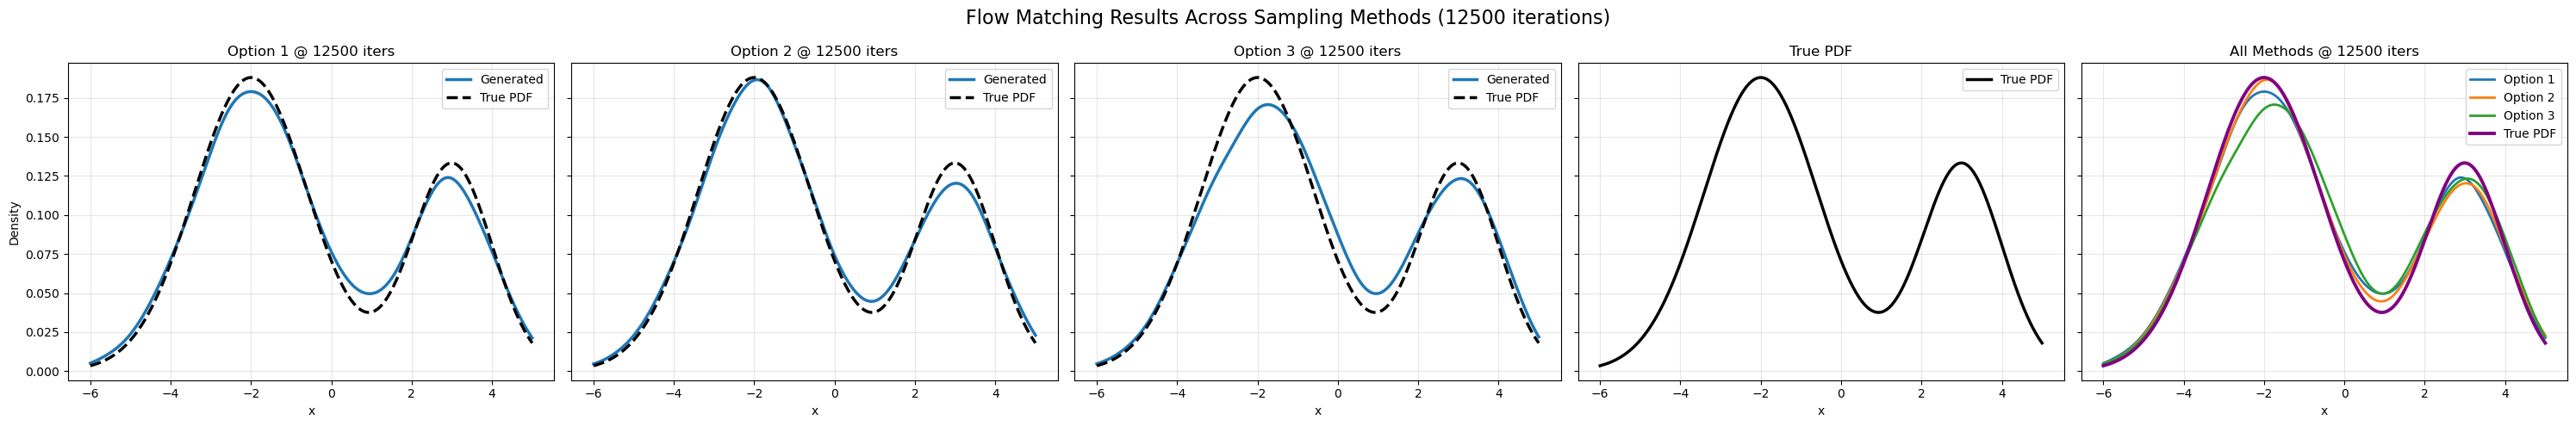

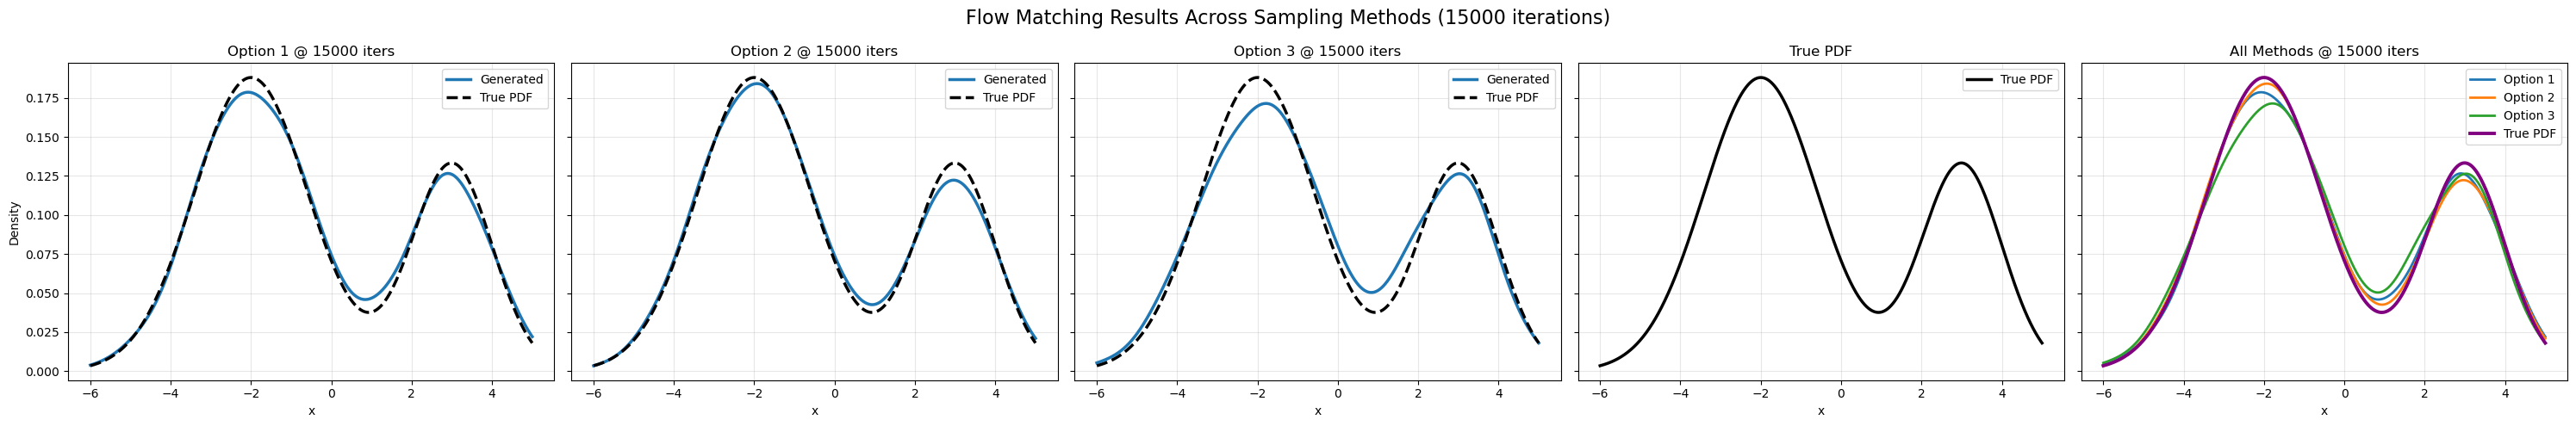

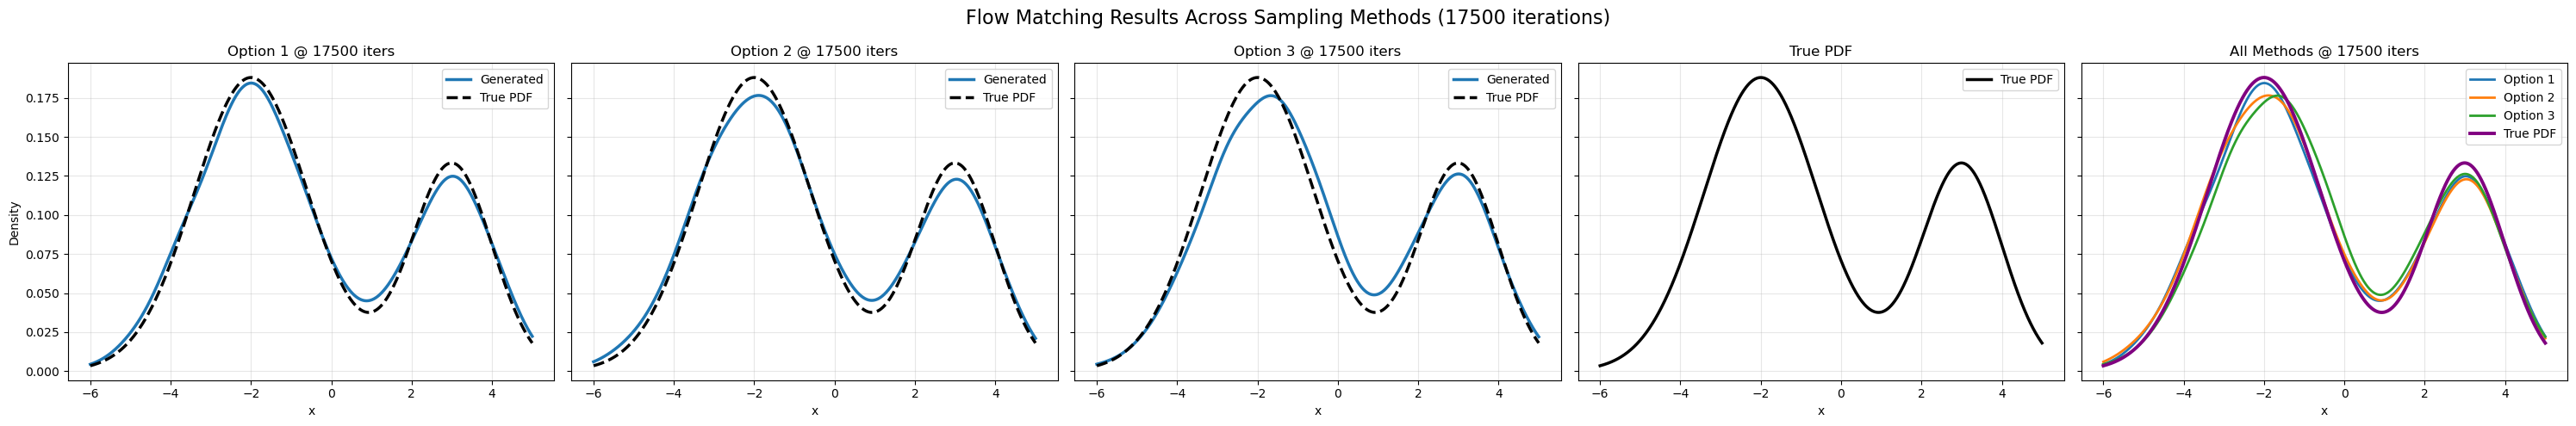

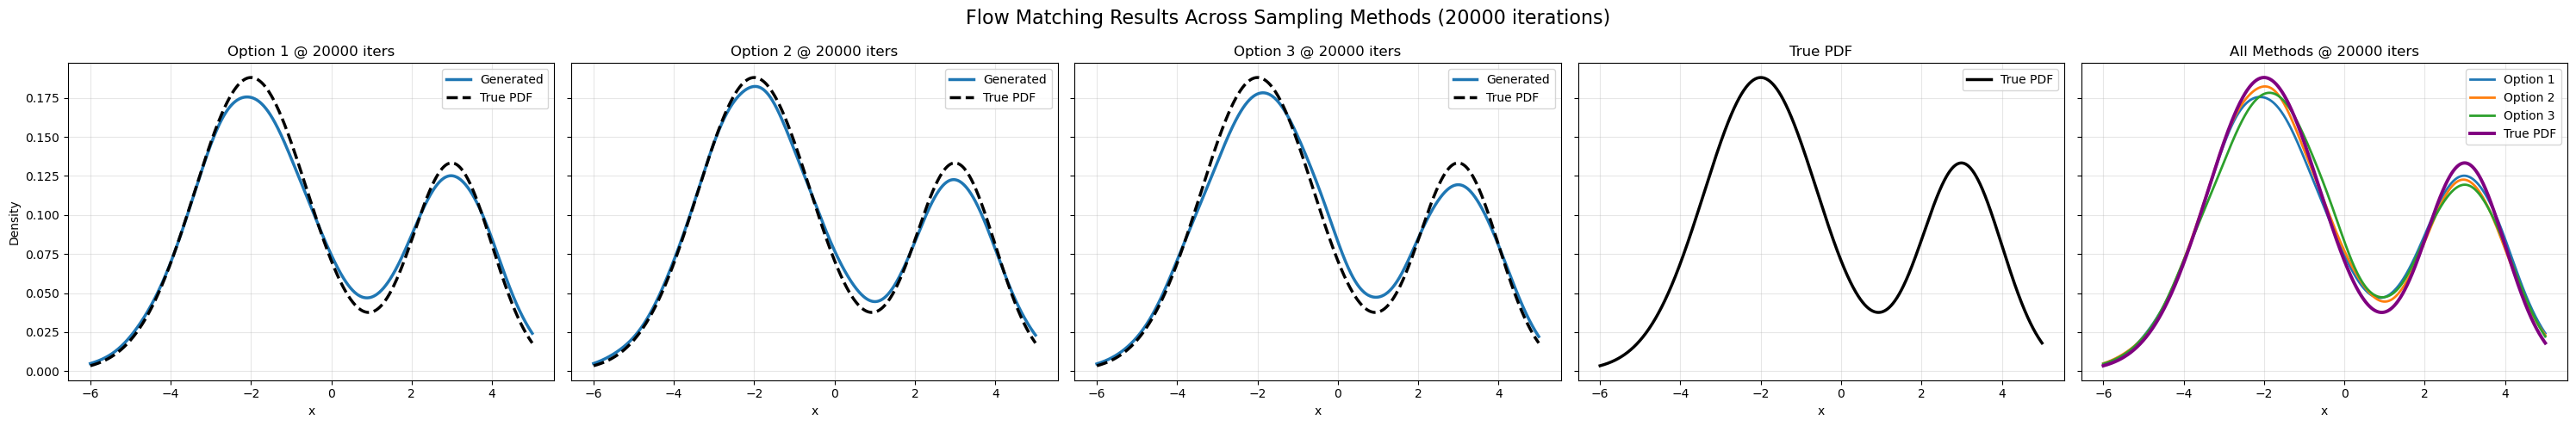

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


def smooth(arr, window=200):
    arr = np.array(arr)
    if window <= 1 or len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window) / window, mode='valid')


# Smoothed overlay comparison 
window = max(1, int(len(losses_option1) * 0.01))
window = 2000
s1 = smooth(losses_option1, window=window)
s2 = smooth(losses_option2, window=window)
s3 = smooth(losses_option3, window=window)
iters_s = np.arange(len(s1)) + (window - 1) // 2

plt.figure(figsize=(12, 6))
plt.plot(iters_s, s1, label=f"Option 1 (smoothed, w={window})", linewidth=2.2, color='C0')
plt.plot(iters_s, s2, label=f"Option 2 (smoothed, w={window})", linewidth=2.2, color='C1')
plt.plot(iters_s, s3, label=f"Option 3 (smoothed, w={window})", linewidth=2.2, color='C2')
for cp in checkpoints:
    plt.axvline(cp, linestyle='--', color='gray', alpha=0.5)
plt.title("Training Loss Across Sampling Methods (Smoothed)")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.legend(loc='upper right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Each subplot
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

#axes[0].plot(losses_option1, color='C0', alpha=0.45)
axes[0].plot(iters_s, s1, color='C0', linewidth=2)
axes[0].set_title("Option 1: Number of Samples")
axes[0].grid(alpha=0.2)
for cp in checkpoints:
    axes[0].axvline(cp, linestyle='--', color='gray', alpha=0.3)

#axes[1].plot(losses_option2, color='C1', alpha=0.45)
axes[1].plot(iters_s, s2, color='C1', linewidth=2)
axes[1].set_title("Option 2: Bernoulli")
axes[1].grid(alpha=0.2)
for cp in checkpoints:
    axes[1].axvline(cp, linestyle='--', color='gray', alpha=0.3)

#axes[2].plot(losses_option3, color='C2', alpha=0.45)
axes[2].plot(iters_s, s3, color='C2', linewidth=2)
axes[2].set_title("Option 3: Weighted Sampling (SUS)")
axes[2].set_xlabel("Iteration")
axes[2].grid(alpha=0.2)
for cp in checkpoints:
    axes[2].axvline(cp, linestyle='--', color='gray', alpha=0.3)

plt.tight_layout()
plt.show()


#KDE plots for each checkpoint
def generate_samples_from_checkpoint(checkpoint_state_dict, n_samples=1000):
    temp_model = MLP(dim=dim, time_varying=True)
    temp_model.load_state_dict(checkpoint_state_dict)
    temp_model.eval()
    with torch.no_grad():
        samples = np.array(generate_fm_samples(temp_model, n_samples=n_samples)).flatten()
    return samples


x_grid = np.linspace(-6, 5, 1000)
pdf_true = true_mixture_pdf(x_grid)

for cp in checkpoints:
    samples_option1 = generate_samples_from_checkpoint(checkpoints_option1[cp], n_samples=10000)
    samples_option2 = generate_samples_from_checkpoint(checkpoints_option2[cp], n_samples=10000)
    samples_option3 = generate_samples_from_checkpoint(checkpoints_option3[cp], n_samples=10000)

    kde1 = gaussian_kde(samples_option1)
    kde2 = gaussian_kde(samples_option2)
    kde3 = gaussian_kde(samples_option3)

    fig, axes = plt.subplots(1, 5, figsize=(30, 5), sharey=True)

    # Option 1
    axes[0].plot(x_grid, kde1(x_grid), linewidth=2.5, label='Generated')
    axes[0].plot(x_grid, pdf_true, linewidth=2.5, linestyle='--', color='black', label='True PDF')
    axes[0].set_title(f"Option 1 @ {cp} iters")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("Density")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # Option 2
    axes[1].plot(x_grid, kde2(x_grid), linewidth=2.5, label='Generated')
    axes[1].plot(x_grid, pdf_true, linewidth=2.5, linestyle='--', color='black', label='True PDF')
    axes[1].set_title(f"Option 2 @ {cp} iters")
    axes[1].set_xlabel("x")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    # Option 3
    axes[2].plot(x_grid, kde3(x_grid), linewidth=2.5, label='Generated')
    axes[2].plot(x_grid, pdf_true, linewidth=2.5, linestyle='--', color='black', label='True PDF')
    axes[2].set_title(f"Option 3 @ {cp} iters")
    axes[2].set_xlabel("x")
    axes[2].grid(alpha=0.3)
    axes[2].legend()

    # True PDF only
    axes[3].plot(x_grid, pdf_true, linewidth=2.5, color='black', label='True PDF')
    axes[3].set_title('True PDF')
    axes[3].set_xlabel("x")
    axes[3].grid(alpha=0.3)
    axes[3].legend()

    # All methods overlaid
    axes[4].plot(x_grid, kde1(x_grid), linewidth=2.0, label='Option 1')
    axes[4].plot(x_grid, kde2(x_grid), linewidth=2.0, label='Option 2')
    axes[4].plot(x_grid, kde3(x_grid), linewidth=2.0, label='Option 3')
    axes[4].plot(x_grid, pdf_true, linewidth=2.8, color='purple', label='True PDF')
    axes[4].set_title(f"All Methods @ {cp} iters")
    axes[4].set_xlabel("x")
    axes[4].grid(alpha=0.3)
    axes[4].legend()

    plt.suptitle(f"Flow Matching Results Across Sampling Methods ({cp} iterations)", fontsize=16)
    plt.tight_layout()
    plt.show()


## Analysis

Instead of changing the weights this time, I opted to change the sampling methods to make them more optimal and i spread out the distributions a bit more so that way they would be less overlapped. We can see clearer results, and Flow Matching performing better as the iterations increase with each sampling method. This is a way better increase since the last version and they pretty much look like the target distribution. The loss kinda bounced around between 4.06 and 4.08 and this may be due to the model converging as we have confirmation from the distribution pictures. The bouncing around may also be due to SGD.

There was some changes to the neural network and optimizer as well. For the neural network it may not have been captruing enough details so I increased the number of neurons and added more layers. For the optimizer I still used Adam, but the changing of the learning rate did not affect it too much. I added a Cosine Scheduler instead and that seemed to help the loss. I also changed the sigma in sample conditional so that way it would be a tighter distribution. 

## SGD

Stochastic Gradient Descent is an optimization algorithm that tries to minimize the loss function. During training it updates the model parameters after an iteration by calculating the loss and takes a step in the negative gradient direction, which essentially means it updates based on where the loss is smallest. It also updates these parameters based on what the learning rate is which can be changed. This happens in one iteration and in the next iteration, this process is repeated.

## Adam Optimzer

Adam optimizer is also called Adaptive Moment Estimation. The key feature of adam optimizer is that adjusts the learning rates during training. It also adjusts individual parameter learning rates. Adam factors in moments where that takes into account a weighted average of past gradients to reduce instability and RMSprop (Root Mean Square Propagation) factors in squared gradients and involves an adaptive learning rate method.

## AdamW Optimizer

AdamW is a form of Adam Optimizer. AdamW treats the weigt decay calculation as independent from the gradient as in Adam. AdamW decouples the weight decay from the learning rates which provides more consistent regularization. AdamW also tends to acheive lower losses due to these two factors.